In [1]:
import math
import numpy
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [2]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    # LR: left to right
    # TB: top to bottom

    assert rankdir in ["LR", "TB"]
    nodes, edges = trace(root)
    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})  # , node_attr={'rankdir': 'TB'})

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for the value.
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape="record")

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [3]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self.label = label

        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        # Derivative of z = x + y with respect to x is 1, and with respect to y is also 1.
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __neg__(self):  # -self
        return self * -1

    def __sub__(self, other):  # self - other
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        # Derivative of z = x * y with respect to x is y, and with respect to y is x.
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):  # other * self
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f"**{other}")

        # Derivative of z = x^n with respect to x is n * x^(n-1).
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad

        out._backward = _backward

        return out

    # a / b = a * (1 / b) = a * b**(-1)
    def __truediv__(self, other):  # self / other
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")

        # Derivative of z = exp(x) with respect to x is exp(x).
        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        # Derivative of z = tanh(x) with respect to x is 1 - tanh^2(x).
        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [4]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(numpy.random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(numpy.random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b, where w * x is the dot product of w and x
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

In [5]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

In [6]:
# MLP = Multi-Layer Perceptron
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

### Mean Squared Error Loss

$\LARGE{MSE = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2}$

Where:
$n$ = number of samples
$Y_i$ = actual value for the i-th sample
$\hat{Y}_i$ = predicted value for the i-th sample

| Formula                   | Graph                      |
| ------------------------- | -------------------------- |
| ![MSE](cs321_mse_01.jpeg) | ![Graph](cs321_mse_02.png) |

In [7]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, -1.0]  # desired targets

mlp = MLP(3, [4, 4, 1])
# predictions from the untrained network
ypred = [mlp(x) for x in xs]
ypred

[Value(data=-0.40937115249601447),
 Value(data=-0.8427902512361118),
 Value(data=-0.48586126579832933),
 Value(data=-0.4360451910035089)]

In [8]:
# gt = ground truth
# how far off are our predictions?
# 0.0 is a perfect score, the higher the worse
[(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)]

[Value(data=1.9863270454879438),
 Value(data=0.024714905106404835),
 Value(data=0.26433863800649615),
 Value(data=0.31804502659026873)]

In [9]:
# sum up the individual losses into a single scalar value
# the summ of the losses is what we want to minimize when we train the network
# 0.0 means perfect predictions, the higher the worse
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.5934256151911135)

In [10]:
loss.backward()
loss

Value(data=2.5934256151911135)

In [11]:
print(mlp.layers[0].neurons[0].w[0])
print(mlp.layers[0].neurons[0].w[0].grad)

Value(data=0.5372221223898814)
0.06873861759220892


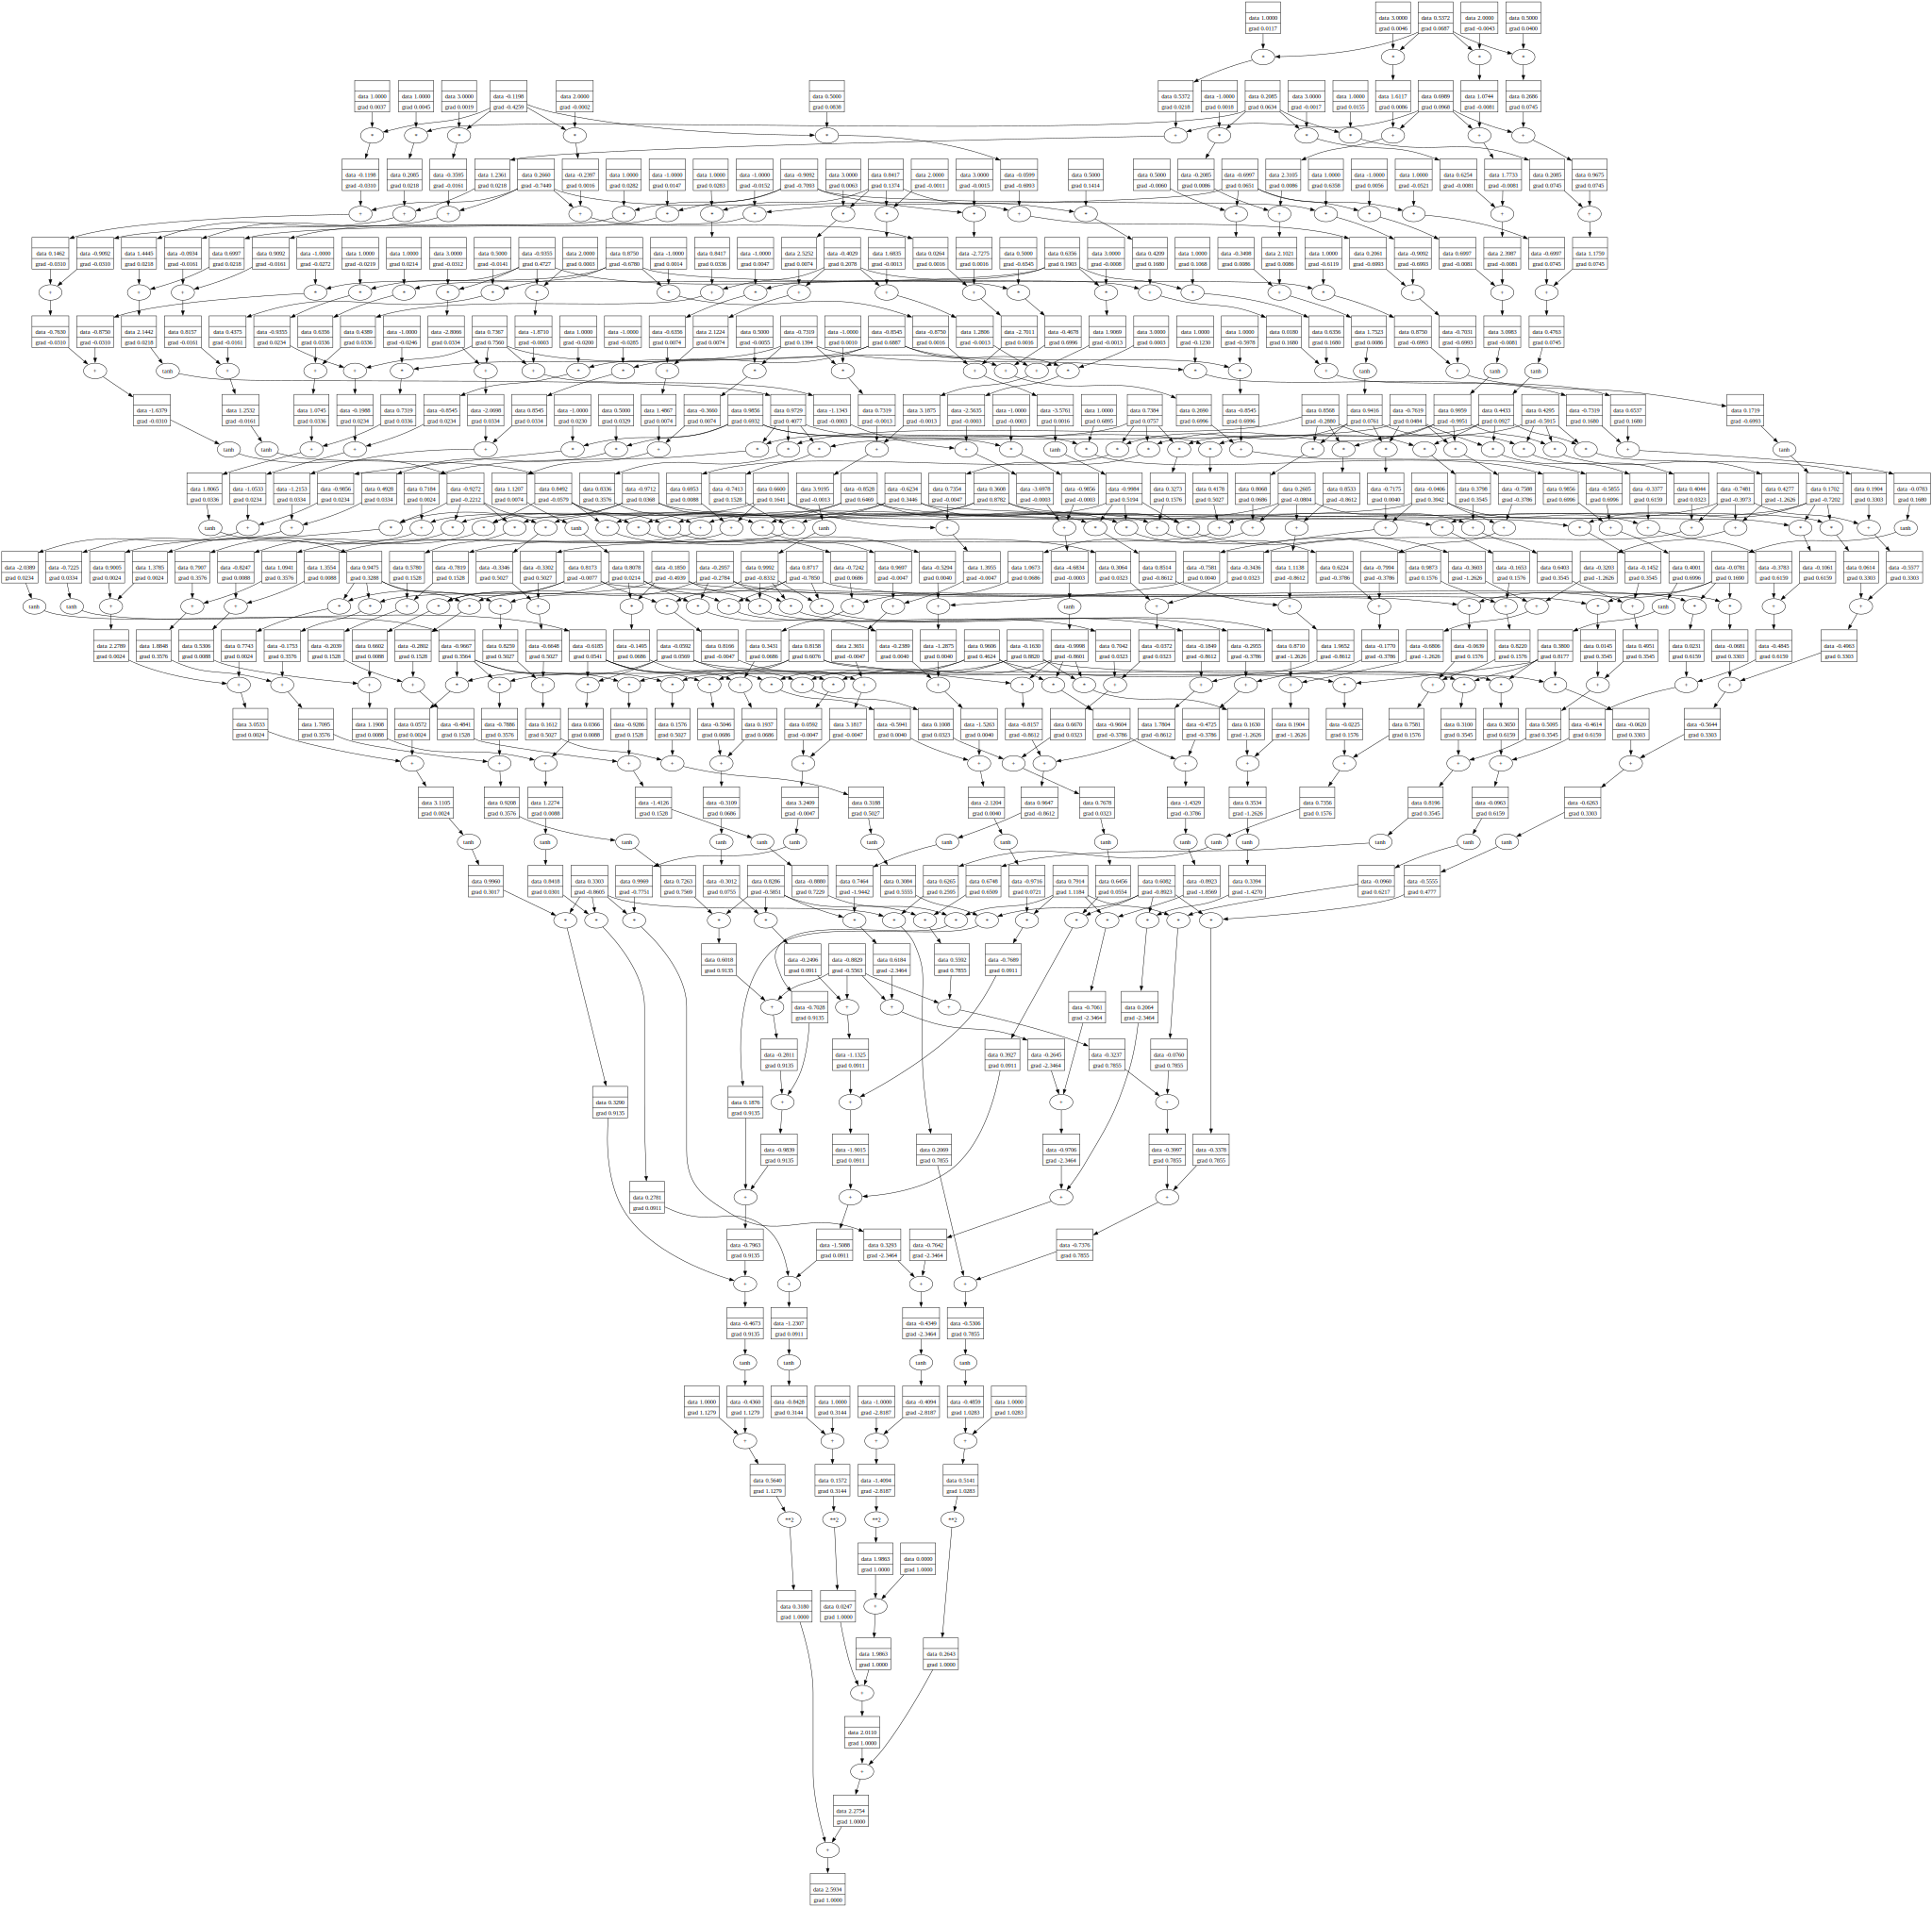

In [12]:
draw_dot(loss, rankdir="TB")